In [2]:
path = r"C:\Escola\Python\Terceira Etapa\indicadores\aula 5\Tabela4.csv"

In [3]:
import pandas as pd
import numpy as np

In [4]:
tabela = pd.read_csv(path, sep=';', header=1, encoding='Windows-1252')



In [5]:
tabela

,Sigla,Cï¿½digo,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,"0,402","0,517","0,663","0,705","0,709","0,719","0,719","0,723","0,711","0,731","0,738","0,736","0,702","0,732","0,74","0,754"
1,AL,27,Alagoas,"0,37","0,471","0,631","0,657","0,653","0,67","0,669","0,68","0,682","0,694","0,693","0,694","0,691","0,722","0,739","0,746"
2,AM,13,Amazonas,"0,43","0,515","0,674","0,706","0,717","0,72","0,724","0,723","0,743","0,732","0,739","0,725","0,7","0,757","0,764","0,767"
3,AP,16,Amapï¿½,"0,472","0,577","0,708","0,709","0,735","0,726","0,728","0,732","0,731","0,737","0,732","0,707","0,681","0,743","0,767","0,759"
4,BA,29,Bahia,"0,386","0,512","0,66","0,684","0,686","0,7","0,708","0,708","0,715","0,714","0,723","0,726","0,698","0,734","0,74","0,759"
5,CE,23,Cearï¿½,"0,405","0,541","0,682","0,709","0,712","0,717","0,723","0,727","0,737","0,746","0,754","0,753","0,74","0,759","0,773","0,773"
6,DF,53,Distrito Federal,"0,616","0,725","0,824","0,824","0,834","0,834","0,833","0,842","0,842","0,845","0,86","0,837","0,823","0,867","0,87","0,866"
7,ES,32,Espï¿½rito Santo,"0,505","0,64","0,74","0,747","0,755","0,763","0,766","0,766","0,769","0,776","0,78","0,773","0,754","0,782","0,803","0,804"
8,GO,52,Goiï¿½s,"0,487","0,615","0,735","0,744","0,753","0,759","0,758","0,765","0,77","0,776","0,78","0,777","0,755","0,797","0,809","0,815"
9,MA,21,Maranhï¿½o,"0,357","0,476","0,639","0,669","0,682","0,683","0,69","0,698","0,704","0,706","0,715","0,715","0,701","0,73","0,74","0,745"


3. Ordene os estados por maior IDH em 2024

In [6]:
ordenando = tabela.sort_values(by='Estado', ascending=True)
estados_ordenados = ordenando[['Sigla','Estado', '2024']]
estados_ordenados

,Sigla,Estado,2024
0,AC,Acre,"0,754"
1,AL,Alagoas,"0,746"
3,AP,Amapï¿½,"0,759"
2,AM,Amazonas,"0,767"
4,BA,Bahia,"0,759"
5,CE,Cearï¿½,"0,773"
6,DF,Distrito Federal,"0,866"
7,ES,Espï¿½rito Santo,"0,804"
8,GO,Goiï¿½s,"0,815"
9,MA,Maranhï¿½o,"0,745"


4. Qual estado teve a maior melhora de IDH entre os anos de 2024 e 1991?

In [10]:
tabela['1991'] = pd.to_numeric(
    tabela['1991'].astype(str).str.replace(',', '.', regex=False)
)

tabela['2024'] = pd.to_numeric(
    tabela['2024'].astype(str).str.replace(',', '.', regex=False)
)

tabela['Diferença'] = tabela['2024'] - tabela['1991']

mlehor_estado = tabela.sort_values(by='Diferença', ascending=False)[['Sigla', 'Estado', '1991', '2024', 'Diferença']]

mlehor_estado.head(1)


,Sigla,Estado,1991,2024,Diferença
26,TO,Tocantins,0.369,0.797,0.428


5. Existe algum estado em que o IDH piorou?

não

In [11]:
piorou = tabela[tabela['Diferença'] < 0]
piorou

,Sigla,Cï¿½digo,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Diferença


6. Passar a tabela inicial do formato largo para o formato longo (`melt`)

In [18]:
anos = [c for c in tabela.columns if str(c).isdigit()]
print(anos)

id_vars = [c for c in tabela.columns if c not in anos]
tabela_melt = tabela.melt(
    id_vars=id_vars,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)
tabela_melt["Ano"] = tabela_melt["Ano"].astype(int)
tabela_melt["IDH"] = pd.to_numeric(tabela_melt["IDH"], errors="coerce")
tabela_melt

['1991', '2000', '2010', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


,Sigla,Cï¿½digo,Estado,Diferença,Ano,IDH
0,AC,12,Acre,0.352,1991,0.402
1,AL,27,Alagoas,0.376,1991,0.370
2,AM,13,Amazonas,0.337,1991,0.430
3,AP,16,Amapï¿½,0.287,1991,0.472
4,BA,29,Bahia,0.373,1991,0.386
...,...,...,...,...,...,...
427,RS,43,Rio Grande do Sul,0.276,2024,0.818
428,SC,42,Santa Catarina,0.290,2024,0.833
429,SE,28,Sergipe,0.353,2024,0.761
430,SP,35,Sï¿½o Paulo,0.260,2024,0.838


7. Plote apenas Minas Gerais

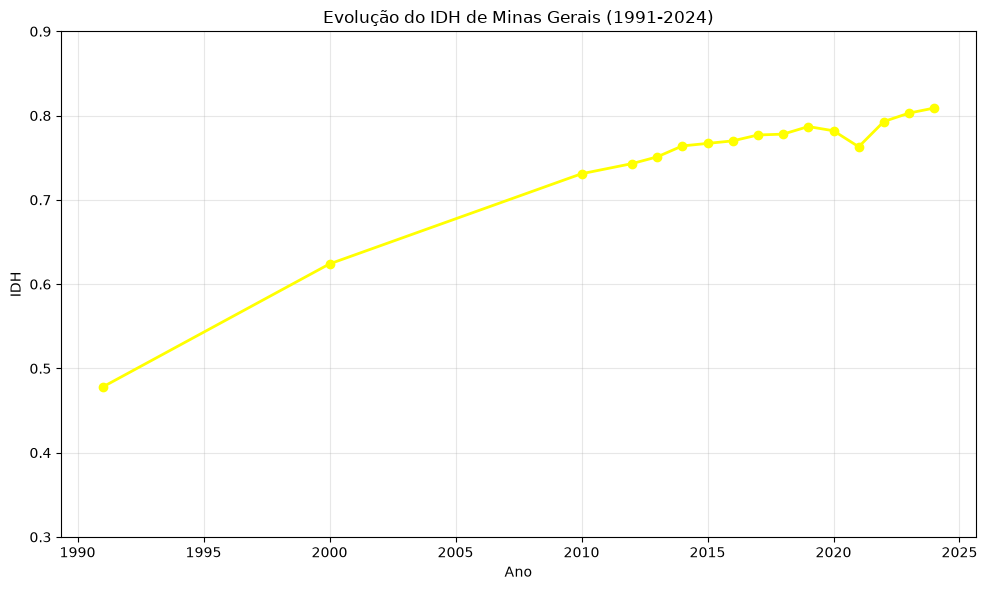

In [20]:
import matplotlib.pyplot as plt

minas_gerais = tabela_melt[tabela_melt["Sigla"] == "MG"].sort_values("Ano")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    minas_gerais["Ano"],
    minas_gerais["IDH"],
    marker="o",
    linewidth=2,
    color="yellow",
)
ax.set_title("Evolução do IDH de Minas Gerais (1991-2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

8. Plote a evolução do IDH de cada estado

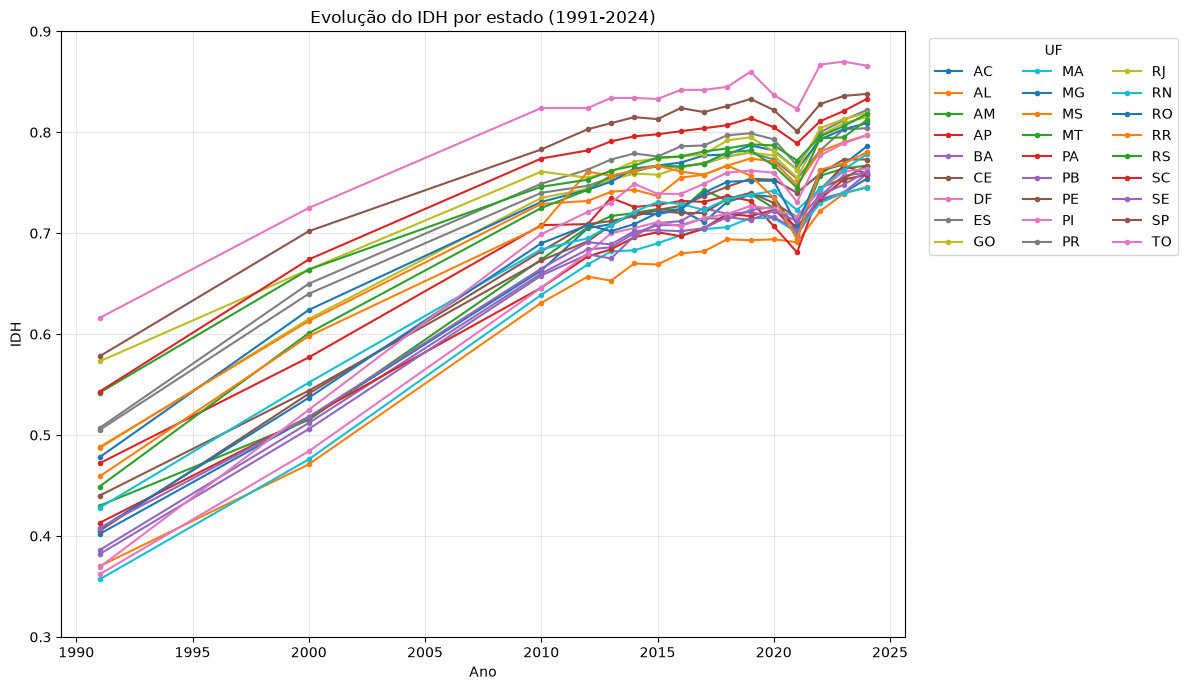

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in tabela_melt.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(
        grupo["Ano"],
        grupo["IDH"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=sigla,
    )

ax.set_title("Evolução do IDH por estado (1991-2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.grid(True, alpha=0.3)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()